# Modal identification

In [1]:
import pyfbs

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Data import

Importing of example data: 
 - experimentally obtained FRFs stored in a pickle file

In [2]:
pyfbs.io.download_lab_testbench()

100%|██████████| 10/10 [00:00<00:00, 31993.17it/s]


100%|██████████| 3/3 [00:00<00:00, 11683.30it/s]


100%|██████████| 10/10 [00:00<00:00, 28130.81it/s]


In [3]:
exp_file = r"./lab_testbench/Measurements/Y_A.p"

### Experimental data import

In [4]:
freq, Y_AB_exp = np.load(exp_file, allow_pickle = True)
Y_AB_exp = np.transpose(Y_AB_exp, (2, 0, 1))
Y_AB_exp.shape # freq, out, inp

c:\Users\OliverZobel\Documents\pyFBS\.venv\Lib\site-packages\numpy\lib\_npyio_impl.py:494: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(fid, **pickle_kwargs)


(801, 6, 6)

### Class initalization

In [5]:
_id = pyfbs.modal_id.ModalID(freq,Y_AB_exp)

### LSCF

In [6]:
_id.p_lscf(max_order=30)

Order:30/30


### Stability chart

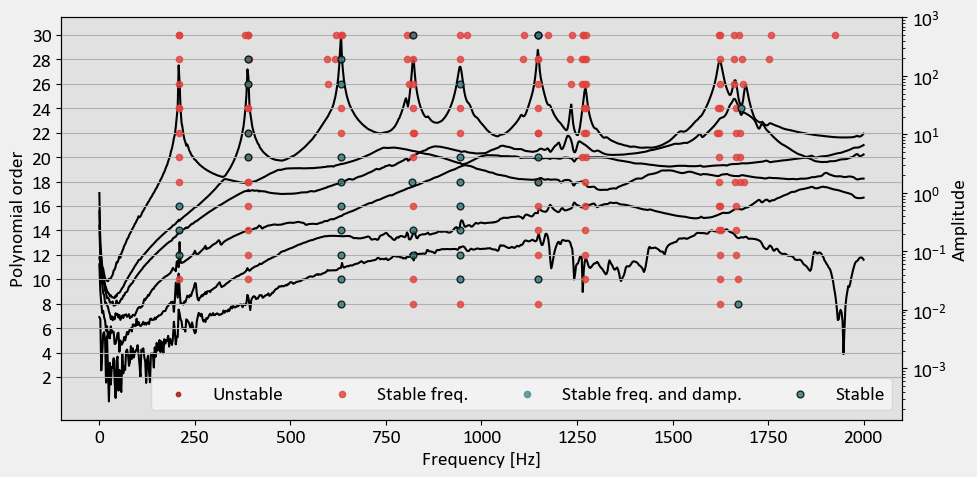

In [7]:
_id.stabilization()

In [8]:
# for automated testing purposes
_id.win.selected_ind = [46, 77, 78, 64, 51, 22]
_id.win.get_modal_data()

### LSFD

In [9]:
_id.p_lsfd(frf_type='accelerance', lower_residuals=False)

### FRF display

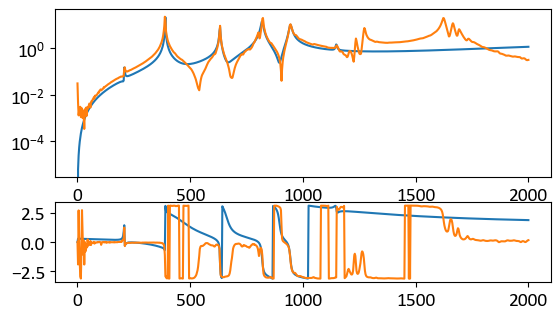

In [11]:
o = 1
i = 1

plt.subplot(211)
plt.semilogy(freq, np.abs(_id.frf_rec[:,o,i]))
plt.semilogy(freq, np.abs(Y_AB_exp[:,o,i]));

plt.subplot(413)
plt.plot(freq, np.angle(_id.frf_rec[:,o,i]))
plt.plot(freq, np.angle(Y_AB_exp[:,o,i]));
plt.show()

In [12]:
_id.nat_freq

array([ 208.17681744,  389.44606224,  631.82413571,  818.62746593,
        944.16425684, 1148.03824056])

In [13]:
_id.damp_ratio

array([0.20075392, 0.08365469, 0.22408743, 0.52895479, 0.55530949,
       0.2839052 ])